# Imports

In [ ]:
# System functionality
import os
import glob 

# Data Analysis
import xarray as xr
import xesmf as xe
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib import colors as mcolors
from matplotlib import ticker as mticker

# Cartopy
from cartopy import crs as ccrs
from cartopy import feature as cfeature
from cartopy import util as cutil
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter, LongitudeLocator, LatitudeLocator

# Auxiliary Functions
from auxiliary_functions.time_utils import datetime64_to_yyyymmdd, string_to_yyyymm, convert_time_to_ns, convert_ns_to_datetime, extract_years_months
from auxiliary_functions import xarray_utils

# Logging
import logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
)
logger = logging.getLogger(__name__)

In [2]:
start_date = "2020-12-29T00:00:00.000000000"
end_date = "2021-02-27T00:00:00.000000000"
logger.info(f"Start date: {start_date}")
logger.info(f"End date: {end_date}")

logger.info("Starting data download script")
def surface_level_preprocess(ds: xr.Dataset) -> xr.Dataset:
    # Subset to a specific region and keep only one variable
    subset_data = ds.sel(
        # level=pressure_levels,
        time=ds.time.where(ds['time'].dt.hour.isin([0, 6, 12, 18]), drop=True)
    )

    target_grid = xr.Dataset(
        {
            "lat": (["lat"], np.arange(-90, 91, 1.0)),
            "lon": (["lon"], np.arange(0, 360, 1.0)),
        }
    )
    regridder = xe.Regridder(subset_data, target_grid, "bilinear", reuse_weights=False) 

    return regridder(subset_data) # type: ignore

def pressure_level_preprocess(ds: xr.Dataset) -> xr.Dataset:
    # Subset to a specific region and keep only one variable
    subset_data = ds.sel(
        level=pressure_levels,
        time=ds.time.where(ds['time'].dt.hour.isin([0, 6, 12, 18]), drop=True)
    ).assign_coords({'level': pressure_levels.astype(np.int32)})

    target_grid = xr.Dataset(
        {
            "lat": (["lat"], np.arange(-90, 91, 1.0)),
            "lon": (["lon"], np.arange(0, 360, 1.0)),
        }
    )
    regridder = xe.Regridder(subset_data, target_grid, "bilinear", reuse_weights=False) 

    return regridder(subset_data) # type: ignore

yyyymm_strings = pd.date_range(
    pd.to_datetime(start_date).to_period("M").to_timestamp(),
    pd.to_datetime(end_date).to_period("M").to_timestamp(),
    freq="MS"
).strftime("%Y%m")

logger.info(f"Dates: {np.datetime64(start_date).astype('datetime64[h]')} : {np.datetime64(end_date).astype('datetime64[h]')}")

graphcast_data_directory = f"/glade/u/home/sressel/spencer-scratch/graphcast_input_data/{string_to_yyyymm(start_date)}_{string_to_yyyymm(end_date)}"
if not os.path.exists(graphcast_data_directory):
    logger.info("Creating output directory...")
    os.makedirs(graphcast_data_directory, exist_ok=True)
logger.info(f"Graphcast data directory: {graphcast_data_directory}")

logger.info("Load all data into a single dataset")
all_data = xr.open_mfdataset(f"{graphcast_data_directory}/*.nc")
logger.info(f"    Saving data...")
all_data.to_netcdf(f"{graphcast_data_directory}/era5_data.nc")
logger.info("Finished")

2026-06-03 17:50:53,345 [INFO] Start date: 2020-12-29T00:00:00.000000000
2026-06-03 17:50:53,345 [INFO] End date: 2021-02-27T00:00:00.000000000
2026-06-03 17:50:53,346 [INFO] Starting data download script
2026-06-03 17:50:53,486 [INFO] Dates: 2020-12-29T00 : 2021-02-27T00
2026-06-03 17:50:53,488 [INFO] Graphcast data directory: /glade/u/home/sressel/spencer-scratch/graphcast_input_data/202012_202102
2026-06-03 17:50:53,489 [INFO] Load all data into a single dataset
2026-06-03 17:50:59,064 [INFO]     Saving data...
2026-06-03 17:51:20,423 [INFO] Finished


In [3]:

years, months = extract_years_months(start_date, end_date)

# Surface level variables
logger.info("Surface level variables")
surface_base = "/gdex/data/d633000/e5.oper.an.sfc"

surface_variables = {
    "2m_temperature": "2t",
    "mean_sea_level_pressure": "msl",
    "10m_u_component_of_wind": "10u",
    "10m_v_component_of_wind": "10v"
}

surface_variables_old_names = {
    "2m_temperature": "VAR_2T",
    "mean_sea_level_pressure": "MSL",
    "10m_u_component_of_wind": "VAR_10U",
    "10m_v_component_of_wind": "VAR_10V"
}

for variable in surface_variables.keys():
    files_list = []

    logger.info(f"  {variable}")
    for ym in yyyymm_strings:
        pattern = f"{surface_base}/{ym}/e5.oper.an.sfc.*_{surface_variables[variable]}.*.nc"
        files_list.extend(glob.glob(pattern))


2026-06-03 16:13:43,075 [INFO] Surface level variables
2026-06-03 16:13:43,076 [INFO]   2m_temperature
2026-06-03 16:13:43,078 [INFO]   mean_sea_level_pressure
2026-06-03 16:13:43,079 [INFO]   10m_u_component_of_wind
2026-06-03 16:13:43,080 [INFO]   10m_v_component_of_wind


# Load RMM data

In [2]:
def load_txt_as_xarray(path):
    # Read the whitespace-delimited file
    df = pd.read_csv(
        path,
        delim_whitespace=True,
        header=None,
        names=["year", "month", "day", "hour", "var1", "var2", "var3"],
        na_values=[-99.0],
    )

    # Build datetime64 index
    df["time"] = pd.to_datetime(df[["year", "month", "day", "hour"]])

    # Set time as index
    df = df.set_index("time")

    # Drop the original date columns
    df = df.drop(columns=["year", "month", "day", "hour"])

    # Convert to xarray Dataset
    ds = xr.Dataset.from_dataframe(df)

    return ds

# Example usage:
RMM_indices = load_txt_as_xarray("RMM.txt")
RMM1 = RMM_indices["var1"]
RMM2 = RMM_indices["var2"]
amplitude = RMM_indices["var3"]


/glade/derecho/scratch/sressel/tmp/ipykernel_99153/2543388944.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


In [2]:
def convert_time_to_ns(ds):
    # Original datetime64 coordinate
    datetime = ds["time"]

    # Compute nanoseconds since first timestep
    t0 = datetime.values[0]
    time_ns = (datetime.values - t0).astype("timedelta64[ns]").astype("timedelta64[ns]")

    new_datetime = datetime.expand_dims('batch').assign_coords(
        datetime=("time", datetime.values),   # secondary coordinate
        time=("time", time_ns)                # replace primary coordinate
    )

    # Assign new coordinates
    ds = ds.expand_dims('batch').assign_coords(
        datetime=new_datetime,
        time=("time", time_ns)
    )

    return ds

In [3]:
start_date = '1992-08-14T00:00:00.000000000'
end_date = '1992-11-12T00:00:00.000000000'
yyyymm_strings = pd.date_range(
    pd.to_datetime(start_date).to_period("M").to_timestamp(),
    pd.to_datetime(end_date).to_period("M").to_timestamp(),
    freq="MS"
).strftime("%Y%m")


def pressure_level_preprocess(ds: xr.Dataset) -> xr.Dataset:
    # Subset to a specific region and keep only one variable
    subset_data = ds.sel(
        level=pressure_levels,
        time=ds.time.where(ds['time'].dt.hour.isin([0, 6, 12, 18]), drop=True)
    ).assign_coords({'level': pressure_levels.astype(np.int32)})

    target_grid = xr.Dataset(
        {
            "lat": (["lat"], np.arange(-90, 91, 1.0)),
            "lon": (["lon"], np.arange(0, 360, 1.0)),
        }
    )
    regridder = xe.Regridder(subset_data, target_grid, "bilinear", reuse_weights=False) 

    return regridder(subset_data) # type: ignore

pressure_level_base = "/gdex/data/d633000/e5.oper.an.pl"

pressure_levels = xr.DataArray(
    data = [50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000],
    dims=['level'],
    coords={'level': [50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000]}
)

pressure_level_variables = {
    "geopotential": "z",
    # "temperature": "t",
    # "u_component_of_wind": "u",
    # "v_component_of_wind": "v",
    # "specific_humidity": "q",
    # "vertical_velocity": "w",
}

pressure_level_variables_old_names = {
    "geopotential": "Z",
    "temperature": "T",
    "u_component_of_wind": "U",
    "v_component_of_wind": "V",
    "specific_humidity": "Q",
    "vertical_velocity": "W",
}

for variable in pressure_level_variables.keys():
    files_list = []

    logger.info(f"  {variable}")
    for ym in yyyymm_strings:
        pattern = f"{pressure_level_base}/{ym}/e5.oper.an.pl.*_{pressure_level_variables[variable]}.*.nc"
        files_list.extend(glob.glob(pattern))

    if not files_list:
        logger.info(f"No files found for variable {variable} in month {ym}")
    else:
        logger.info(f"    Loading files...")
        pressure_level_data = xr.open_mfdataset(sorted(files_list)[:3], preprocess=pressure_level_preprocess).load()


2026-05-20 13:34:06,340 [INFO]   geopotential
2026-05-20 13:34:06,350 [INFO]     Loading files...


In [43]:
# yyyymm_strings
pressure_level_data.coords['time']
# sorted(files_list)

# xr.open_dataset("/gdex/data/d633000/e5.oper.an.pl/199208/e5.oper.an.pl.128_130_t.ll025sc.1992080100_1992080123.nc")

<xarray.DataArray 'time' (time: 12)> Size: 96B
array(['1992-08-01T00:00:00.000000000', '1992-08-01T06:00:00.000000000',
       '1992-08-01T12:00:00.000000000', '1992-08-01T18:00:00.000000000',
       '1992-08-02T00:00:00.000000000', '1992-08-02T06:00:00.000000000',
       '1992-08-02T12:00:00.000000000', '1992-08-02T18:00:00.000000000',
       '1992-08-03T00:00:00.000000000', '1992-08-03T06:00:00.000000000',
       '1992-08-03T12:00:00.000000000', '1992-08-03T18:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 96B 1992-08-01 ... 1992-08-03T18:00:00

In [45]:
target_duration

Timedelta('10 days 00:00:00')

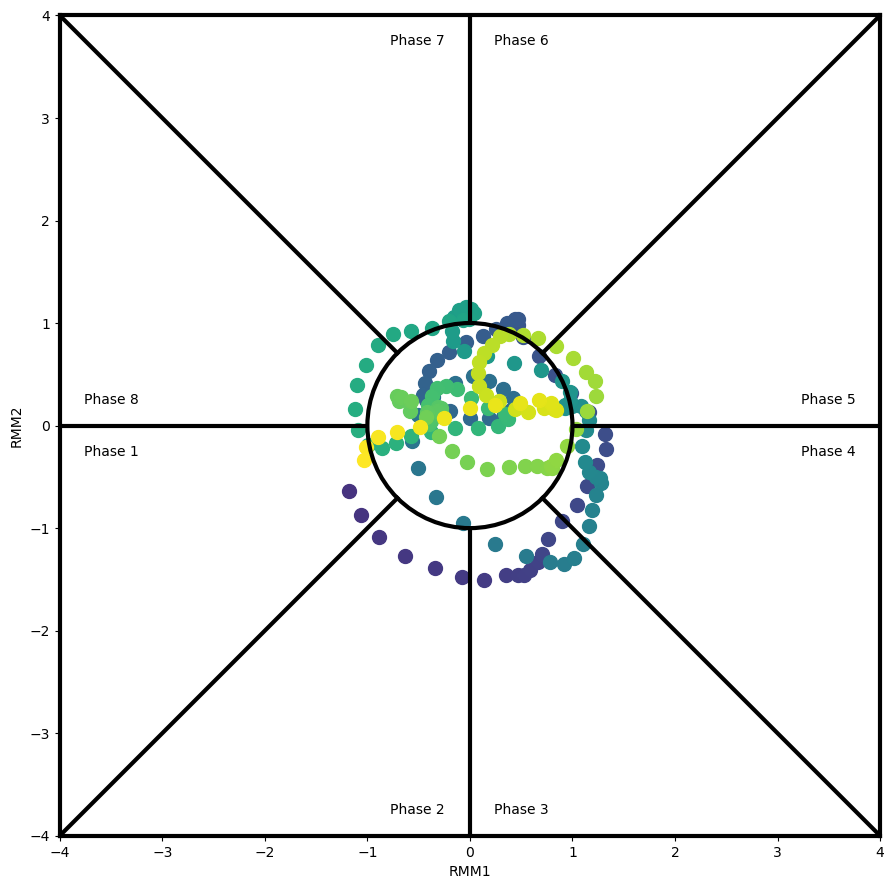

In [48]:
# plt.scatter(
#     RMM1.isel(time=slice(3371-100, 3371+100)),
#     RMM2.isel(time=slice(3371-100, 3371+100)),
# )
# plt.xlim(-4, 4)
# plt.ylim(-4, 4)
# plt.gca().set_aspect('equal')

# Configure plot
[fig, ax] = plt.subplots(figsize=(9,9))
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 3
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
plt.xlabel("RMM1")
plt.ylabel("RMM2")
ax.set_facecolor("white")

# Plot index points
colormap = sns.color_palette("viridis", as_cmap=True)
start_time = '2009-10-01T00:00:00.000000000'
end_time = '2010-04-30T00:00:00.000000000'
start_index = list(amplitude.time.values).index(amplitude.sel(time=start_time).time)
end_index = list(amplitude.time.values).index(amplitude.sel(time=end_time).time)
ax.plot(RMM1[start_index], RMM2[start_index], color="black", marker=".", ls="-", ms=30)
for i in range(start_index + 1, end_index + 1):
    ax.plot(
        RMM1[i],
        RMM2[i],
        color=colormap((i - start_index) / (end_index - start_index)),
        marker="o",
        ms=10,
    )

# Add phase regions overlay
circle1 = plt.Circle((0, 0), 1.0, color="k", fill=False, lw=3, zorder=10)
ax.hlines(y=0, xmin=-4, xmax=-1, color="k", lw=3, ls="-")
ax.hlines(y=0, xmin=1, xmax=4, color="k", lw=3, ls="-")
ax.vlines(x=0, ymin=-4, ymax=-1, color="k", lw=3, ls="-")
ax.vlines(x=0, ymin=1, ymax=4, color="k", lw=3, ls="-")
ax.plot([np.sqrt(2) / 2, 4], [np.sqrt(2) / 2, 4], color="k", lw=3, ls="-")


x_vals = {
    1:-1,
    2:-1,
    3:1,
    4:1,
    5:1,
    6:1,
    7:-1,
    8:-1
}

y_val1 = {
    1:0,
    2:-4,
    3:-4,
    4:0,
    5:0,
    6:np.linspace(0,4,len(RMM1)),
    7:np.linspace(0,4,len(RMM1)),
    8:0
}

y_val2 = {
    1:-1*np.linspace(0, 4, len(RMM1)),
    2:-1*np.linspace(0, 4, len(RMM1)),
    3:-1*np.linspace(0, 4, len(RMM1)),
    4:-1*np.linspace(0, 4, len(RMM1)),
    5:1*np.linspace(0, 4, len(RMM1)),
    6:4,
    7:4,
    8:1*np.linspace(0, 4, len(RMM1))
}

# Fill one of the phases in with blue
# val=2
# ax.fill_between(
#     x_vals[val]*np.linspace(0, 4, len(RMM1)), 
#     y_val1[val], 
#     y_val2[val]
# )

# x = np.linspace(-1,1,100)
# ax.fill_between(x, -np.sqrt(1-x**2), np.sqrt(1-x**2), color='white')

# Add lines to differentiate the phases
ax.plot([np.sqrt(2) / 2, 4], [-np.sqrt(2) / 2, -4], color="k", lw=3, ls="-")
ax.plot([-4, -np.sqrt(2) / 2], [4, np.sqrt(2) / 2], color="k", lw=3, ls="-")
ax.plot([-4, -np.sqrt(2) / 2], [-4, -np.sqrt(2) / 2], color="k", lw=3, ls="-")
ax.add_patch(circle1)

# Add phase labels
ax.text(-3.5, -0.26, f'Phase 1',  horizontalalignment='center',
     verticalalignment='center')
ax.text(-0.51, -3.75, f'Phase 2', horizontalalignment='center',
     verticalalignment='center')
ax.text(0.5, -3.75, f'Phase 3',   horizontalalignment='center',
     verticalalignment='center')
ax.text(3.5, -0.26, f'Phase 4',   horizontalalignment='center',
     verticalalignment='center')
ax.text(3.5, 0.25, f'Phase 5',    horizontalalignment='center',
     verticalalignment='center')
ax.text(0.5, 3.75, f'Phase 6',    horizontalalignment='center',
     verticalalignment='center')
ax.text(-0.51, 3.75, f'Phase 7',  horizontalalignment='center',
     verticalalignment='center')
ax.text(-3.5, 0.25, f'Phase 8',   horizontalalignment='center',
     verticalalignment='center')

# Add MJO-location labels
# ax.text(0, 3.5, f'Western Pacific',  horizontalalignment='center',
#      verticalalignment='center', bbox=props, fontsize=14)

# ax.text(-3.3, 0, f'Western Hemisphere \n & Africa',  horizontalalignment='center',
#      verticalalignment='center', bbox=props, fontsize=14)

# ax.text(3.3, 0, f'Maritime Continent',  horizontalalignment='center',
#      verticalalignment='center', bbox=props, fontsize=14)

# ax.text(0, -3.5, f'Indian Ocean',  horizontalalignment='center',
#      verticalalignment='center', bbox=props, fontsize=14)

ax.set_aspect("equal")
plt.tight_layout()

plt.show()

# Process ERA5 data

## Download ERA5 data

In [ ]:
# start_time = "2021-05-01"
# end_time = "2022-12-31"

start_time = "1974-00-01"
end_time = "1979-12-31"

variable = 'zonal_wind'

variable_name = {
    'zonal_wind':'u_component_of_wind',
    'meridional_wind':'v_component_of_wind'
    }

from datetime import datetime
from dateutil.relativedelta import relativedelta

def iter_year_months(start, end):
    """
    Yield (year, month) pairs for all months between two arbitrary dates.
    Accepts datetime objects or ISO-format strings.
    """

    # Parse strings if needed
    if isinstance(start, str):
        start = datetime.fromisoformat(start)
    if isinstance(end, str):
        end = datetime.fromisoformat(end)

    # Normalize to first-of-month
    cursor = start.replace(day=1)
    end_month = end.replace(day=1)

    while cursor <= end_month:
        yield cursor.year, cursor.month
        cursor += relativedelta(months=1)

import cdsapi

c = cdsapi.Client()

for year, month in iter_year_months(start_time, end_time):
    print(year, month)
    output_file = f"/glade/derecho/scratch/sressel/ECMWF/ERA5/daily_data/daily_25_degree_{variable}_{year}_{month}_raw.nc"
    c.retrieve(
        "reanalysis-era5-pressure-levels",
        {
            "product_type": "reanalysis",
            "variable": [
                variable_name[variable],
                # "v_component_of_wind",
            ],
            "pressure_level": [
                "100", "125", "150", "175", "200", "225", "250", "300", "350", "400",
                "450", "500", "550", "600", "650", "700", "750", "775", "800", "825",
                "850", "875", "900", "925", "950", "975", "1000",
            ],
            "year": year,
            "month": month,
            "day": [
                "01","02","03","04","05","06","07","08","09","10",
                "11","12","13","14","15","16","17","18","19","20",
                "21","22","23","24","25","26","27","28","29","30","31",
            ],
            "time": ["00:00"],   # daily at 00 UTC
            "area": [30, -180, -30, 180],  # North, West, South, East
            "grid": [2.5, 2.5],  # 2.5° x 2.5°
            "format": "netcdf",
        },
        output_file,
    )

# data_processed = xr.open_dataset("/glade/u/home/sressel/spencer-scratch/ECMWF/ERA5/daily_data/daily_25_degree_{variable}_{start_time.year}_{end_time.year}_raw.nc").rename(
#     {
#         'longitude': 'lon',
#         'latitude': 'lat',
#         'valid_time': 'time',
#         'pressure_level': 'plev',
#     }
# ).transpose("time", "plev", "lat", "lon").isel(plev=slice(None, None, -1)).sortby('plev').sortby('lat').coord_funcs.lon_to_360('lon')
# data_processed.to_netcdf("/glade/u/home/sressel/spencer-scratch/ECMWF/ERA5/daily_data/daily_25_degree_{variable}_{start_time.year}_{end_time.year}.nc")


# Load Graphcast sample data

In [4]:
gc_data = xr.open_dataset("/glade/u/home/sressel/thesis-work/python/graphcast/gc-initial-condition-optimization/data/era5_sample.nc")
gc_data.coords['datetime']

<xarray.DataArray 'datetime' (batch: 1, time: 14)> Size: 112B
[14 values with dtype=datetime64[ns]]
Coordinates:
  * time      (time) timedelta64[ns] 112B 0 days 00:00:00 ... 3 days 06:00:00
    datetime  (batch, time) datetime64[ns] 112B ...
Dimensions without coordinates: batch

In [5]:
from typing import Any, Mapping, Sequence, Tuple, Union

TimedeltaLike = Any  # Something convertible to pd.Timedelta.
TimedeltaStr = str  # A string convertible to pd.Timedelta.

TargetLeadTimes = Union[
    TimedeltaLike,
    Sequence[TimedeltaLike],
    slice  # with TimedeltaLike as its start and stop.
]
def _process_target_lead_times_and_get_duration(
    target_lead_times: TargetLeadTimes) -> TimedeltaLike:
  """Returns the minimum duration for the target lead times."""
  if isinstance(target_lead_times, slice):
    # A slice of lead times. xarray already accepts timedelta-like values for
    # the begin/end/step of the slice.
    if target_lead_times.start is None:
      # If the start isn't specified, we assume it starts at the next timestep
      # after lead time 0 (lead time 0 is the final input timestep):
      target_lead_times = slice(
          pd.Timedelta(1, "ns"), target_lead_times.stop, target_lead_times.step
      )
    target_duration = pd.Timedelta(target_lead_times.stop)
  else:
    if not isinstance(target_lead_times, (list, tuple, set)):
      # A single lead time, which we wrap as a length-1 array to ensure there
      # still remains a time dimension (here of length 1) for consistency.
      target_lead_times = [target_lead_times]

    # A list of multiple (not necessarily contiguous) lead times:
    target_lead_times = [pd.Timedelta(x) for x in target_lead_times]
    target_lead_times.sort()
    target_duration = target_lead_times[-1]
  return target_lead_times, target_duration

target_lead_times = slice("6h", f"{40*6}h")
(target_lead_times, target_duration
   ) = _process_target_lead_times_and_get_duration(target_lead_times)
target_duration
time = gc_data.coords["time"]
new_gc_data = gc_data.assign_coords(time=time + target_duration - time[-1])

In [2]:
from graphcast import autoregressive
from graphcast import casting
from graphcast import checkpoint
from graphcast import data_utils
from graphcast import graphcast
from graphcast import normalization
from graphcast import rollout
from graphcast import xarray_jax
from graphcast import xarray_tree
params_file_path = "/glade/u/home/sressel/thesis-work/python/graphcast/gc-initial-condition-optimization/params/params_GraphCast_small.npz"

def load_params(params_file_path=None):
    if params_file_path is None:
        params_file_path = os.environ.get('GRAPHCAST_PARAMS_PATH', 'params/params_GraphCast_small.npz')

    with open(params_file_path, "rb") as f:
        ckpt = checkpoint.load(f, graphcast.CheckPoint)
        return ckpt.params, ckpt.model_config, ckpt.task_config, ckpt.description
    
params, model_config, task_config, model_description = load_params(params_file_path="/glade/u/home/sressel/thesis-work/python/graphcast/gc-initial-condition-optimization/params/params_GraphCast_small.npz")

In [43]:
np.load("/glade/u/home/sressel/thesis-work/python/graphcast/gc-initial-condition-optimization/params/params_GraphCast_small.npz")['task_config:input_duration']
# task_config.input_duration

array('12h', dtype='<U3')

In [4]:
# Surface level variables
logger.info("Surface level variables")
surface_base = "/gdex/data/d633000/e5.oper.an.sfc"

surface_variables = {
    "2m_temperature": "2t",
    # "mean_sea_level_pressure": "msl",
    # "10m_u_component_of_wind": "10u",
    # "10m_v_component_of_wind": "10v"
}

surface_variables_old_names = {
    "2m_temperature": "VAR_2T",
    # "mean_sea_level_pressure": "MSL",
    # "10m_u_component_of_wind": "VAR_10U",
    # "10m_v_component_of_wind": "VAR_10V"
}

for variable in surface_variables.keys():
    files_list = []

    logger.info(f"  {variable}")
    for ym in yyyymm_strings:
        pattern = f"{surface_base}/{ym}/e5.oper.an.sfc.*_{surface_variables[variable]}.*.nc"
        files_list.extend(glob.glob(pattern))

    if not files_list:
        print(f"No files found for variable {variable} in month {ym}")
    else:
        logger.info(f"    Loading files...")
        surface_data = convert_time_to_ns(xr.open_mfdataset(sorted(files_list), preprocess=surface_level_preprocess).load())
        surface_data = surface_data.rename({surface_variables_old_names[variable]: variable})
        datetimes = surface_data.datetime


2026-06-03 16:14:01,330 [INFO] Surface level variables
2026-06-03 16:14:01,331 [INFO]   2m_temperature
2026-06-03 16:14:01,334 [INFO]     Loading files...


In [5]:
datetimes

<xarray.DataArray 'datetime' (batch: 1, time: 360)> Size: 3kB
array([['2020-12-01T00:00:00.000000000', '2020-12-01T06:00:00.000000000',
        '2020-12-01T12:00:00.000000000', '2020-12-01T18:00:00.000000000',
        '2020-12-02T00:00:00.000000000', '2020-12-02T06:00:00.000000000',
        '2020-12-02T12:00:00.000000000', '2020-12-02T18:00:00.000000000',
        '2020-12-03T00:00:00.000000000', '2020-12-03T06:00:00.000000000',
        '2020-12-03T12:00:00.000000000', '2020-12-03T18:00:00.000000000',
        '2020-12-04T00:00:00.000000000', '2020-12-04T06:00:00.000000000',
        '2020-12-04T12:00:00.000000000', '2020-12-04T18:00:00.000000000',
        '2020-12-05T00:00:00.000000000', '2020-12-05T06:00:00.000000000',
        '2020-12-05T12:00:00.000000000', '2020-12-05T18:00:00.000000000',
        '2020-12-06T00:00:00.000000000', '2020-12-06T06:00:00.000000000',
        '2020-12-06T12:00:00.000000000', '2020-12-06T18:00:00.000000000',
        '2020-12-07T00:00:00.000000000', '2020-12-07T06:00:00.000000000',
        '2020-12-07T12:00:00.000000000', '2020-12-07T18:00:00.000000000',
        '2020-12-08T00:00:00.000000000', '2020-12-08T06:00:00.000000000',
        '2020-12-08T12:00:00.000000000', '2020-12-08T18:00:00.000000000',
        '2020-12-09T00:00:00.000000000', '2020-12-09T06:00:00.000000000',
        '2020-12-09T12:00:00.000000000', '2020-12-09T18:00:00.000000000',
        '2020-12-10T00:00:00.000000000', '2020-12-10T06:00:00.000000000',
        '2020-12-10T12:00:00.000000000', '2020-12-10T18:00:00.000000000',
...
        '2021-02-19T12:00:00.000000000', '2021-02-19T18:00:00.000000000',
        '2021-02-20T00:00:00.000000000', '2021-02-20T06:00:00.000000000',
        '2021-02-20T12:00:00.000000000', '2021-02-20T18:00:00.000000000',
        '2021-02-21T00:00:00.000000000', '2021-02-21T06:00:00.000000000',
        '2021-02-21T12:00:00.000000000', '2021-02-21T18:00:00.000000000',
        '2021-02-22T00:00:00.000000000', '2021-02-22T06:00:00.000000000',
        '2021-02-22T12:00:00.000000000', '2021-02-22T18:00:00.000000000',
        '2021-02-23T00:00:00.000000000', '2021-02-23T06:00:00.000000000',
        '2021-02-23T12:00:00.000000000', '2021-02-23T18:00:00.000000000',
        '2021-02-24T00:00:00.000000000', '2021-02-24T06:00:00.000000000',
        '2021-02-24T12:00:00.000000000', '2021-02-24T18:00:00.000000000',
        '2021-02-25T00:00:00.000000000', '2021-02-25T06:00:00.000000000',
        '2021-02-25T12:00:00.000000000', '2021-02-25T18:00:00.000000000',
        '2021-02-26T00:00:00.000000000', '2021-02-26T06:00:00.000000000',
        '2021-02-26T12:00:00.000000000', '2021-02-26T18:00:00.000000000',
        '2021-02-27T00:00:00.000000000', '2021-02-27T06:00:00.000000000',
        '2021-02-27T12:00:00.000000000', '2021-02-27T18:00:00.000000000',
        '2021-02-28T00:00:00.000000000', '2021-02-28T06:00:00.000000000',
        '2021-02-28T12:00:00.000000000', '2021-02-28T18:00:00.000000000']],
      dtype='datetime64[ns]')
Coordinates:
    datetime  (batch, time) datetime64[ns] 3kB 2020-12-01 ... 2021-02-28T18:0...
  * time      (time) timedelta64[ns] 3kB 0 days 00:00:00 ... 89 days 18:00:00
Dimensions without coordinates: batch

In [ ]:
# import cdsapi
# # Precipitation
# logger.info("Precipitation")
# target = f"{graphcast_data_directory}/total_precipitation_6hr.nc"
# dataset = "reanalysis-era5-single-levels"
# request = {
#     "product_type": ["reanalysis"],
#     "variable": [
#         "total_precipitation",
#     ],
#     "year": years,
#     "month": months,
#     "day": [
#         "01", "02", "03",
#         "04", "05", "06",
#         "07", "08", "09",
#         "10", "11", "12",
#         "13", "14", "15",
#         "16", "17", "18",
#         "19", "20", "21",
#         "22", "23", "24",
#         "25", "26", "27",
#         "28", "29", "30",
#         "31"
#     ],
#     "time": [
#         "00:00", "01:00", "02:00",
#         "03:00", "04:00", "05:00",
#         "06:00", "07:00", "08:00",
#         "09:00", "10:00", "11:00",
#         "12:00", "13:00", "14:00",
#         "15:00", "16:00", "17:00",
#         "18:00", "19:00", "20:00",
#         "21:00", "22:00", "23:00"
#     ],
#     "data_format": "netcdf",
#     "download_format": "unarchived"
# }

# client = cdsapi.Client()
# logger.info("    Downloading data...")
# client.retrieve(dataset, request, target)

# logger.info("    Regridding data...")
# raw_precipitation_files = sorted(glob.glob(f"{graphcast_data_directory}/total_precipitation_6hr.nc"))
# precipitation_data = xr.open_mfdataset(raw_precipitation_files)['tp'].rename({'valid_time': 'time'}).load()

# six_hour_accumulated_precipitation = precipitation_data.resample(time='6h').sum()

# target_grid = xr.Dataset(
#         {
#             "lat": (["lat"], np.arange(-90, 91, 1.0)),
#             "lon": (["lon"], np.arange(0, 360, 1.0)),
#         }
#     )
# regridder = xe.Regridder(six_hour_accumulated_precipitation, target_grid, "bilinear", reuse_weights=False)
# regridded_precipitation = regridder(six_hour_accumulated_precipitation)
# regridded_precipitation = convert_time_to_ns(regridded_precipitation.sel(time=datetimes.sel(batch=0).values))

# regridded_precipitation.name = 'total_precipitation_6hr'
# resave_data = True
# if resave_data:
#     logger.info(f"    Output directory: {graphcast_data_directory}")
#     logger.info(f"    Saving data...")
#     regridded_precipitation.to_netcdf(f"{graphcast_data_directory}/total_precipitation_6hr.nc", mode='w')
#     regridded_precipitation.close()
#     del regridded_precipitation
#     gc.collect()

# logger.info("Finished")

# TOA Solar Radiation
logger.info("TOA Solar Radiation")
target = f"{graphcast_data_directory}/toa_incident_solar_radiation.nc"
dataset = "reanalysis-era5-single-levels"
request = {
    "product_type": ["reanalysis"],
    "variable": [
        "toa_incident_solar_radiation"
    ],
    "year": years,
    "month": months,
    "day": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12",
        "13", "14", "15",
        "16", "17", "18",
        "19", "20", "21",
        "22", "23", "24",
        "25", "26", "27",
        "28", "29", "30",
        "31"
    ],
    "time": [
        "00:00", "06:00","12:00","18:00"
    ],
    "data_format": "netcdf",
    "download_format": "unarchived"
}

import gc
client = cdsapi.Client()
logger.info("    Downloading data...")
client.retrieve(dataset, request, target)

logger.info("    Regridding data...")
toa_incident_solar_radiation_data = xr.open_mfdataset(target)['tisr'].rename({'valid_time':'time'}).load()

target_grid = xr.Dataset(
        {
            "lat": (["lat"], np.arange(-90, 91, 1.0)),
            "lon": (["lon"], np.arange(0, 360, 1.0)),
        }
    )
regridder = xe.Regridder(toa_incident_solar_radiation_data, target_grid, "bilinear", reuse_weights=False)
regridded_toa_incident_solar_radiation = regridder(toa_incident_solar_radiation_data)
regridded_toa_incident_solar_radiation = convert_time_to_ns(regridded_toa_incident_solar_radiation.sel(time=datetimes.sel(batch=0).values))
regridded_toa_incident_solar_radiation.name = 'toa_incident_solar_radiation'

resave_data = True
if resave_data:
    logger.info(f"    Output directory: {graphcast_data_directory}")
    logger.info(f"    Saving data...")
    regridded_toa_incident_solar_radiation.to_netcdf(f"{graphcast_data_directory}/toa_incident_solar_radiation.nc", mode='w')
    regridded_toa_incident_solar_radiation.close()
    del regridded_toa_incident_solar_radiation
    gc.collect()


2026-06-03 16:24:39,191 [INFO] TOA Solar Radiation
2026-06-03 16:24:39,888 [INFO]     Downloading data...
2026-06-03 16:24:40,500 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-06-03 16:24:40,500 [INFO] [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](ht

In [29]:
# era5_data = xr.open_dataset(f"{graphcast_data_directory}/era5_data.nc")
# precipitation_data = xr.open_dataset("/glade/u/home/sressel/spencer-scratch/graphcast_input_data/202012_202102/total_precipitation_6hr.nc")['tp'].rename({'valid_time': 'time'}).load()
# six_hour_accumulated_precipitation = precipitation_data.resample(time='6h').sum()

# target_grid = xr.Dataset(
#         {
#             "lat": (["lat"], np.arange(-90, 91, 1.0)),
#             "lon": (["lon"], np.arange(0, 360, 1.0)),
#         }
#     )
# regridder = xe.Regridder(six_hour_accumulated_precipitation, target_grid, "bilinear", reuse_weights=False)
# regridded_precipitation = regridder(six_hour_accumulated_precipitation)
regridded_precipitation = convert_time_to_ns(regridded_precipitation.sel(time=datetimes.sel(batch=0).values))

In [30]:
regridded_precipitation

<xarray.DataArray (batch: 1, time: 360, lat: 181, lon: 360)> Size: 94MB
array([[[[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [5.72204590e-06, 6.19888306e-06, 6.19888306e-06, ...,
          4.76837158e-06, 5.24520874e-06, 5.72204590e-06],
         [2.28881836e-05, 2.47955322e-05, 2.57492065e-05, ...,
          1.90734863e-05, 2.00271606e-05, 2.09808350e-05],
         ...,
         [1.92642212e-04, 1.89304352e-04, 1.86443329e-04, ...,
          1.91211700e-04, 1.88827515e-04, 1.91211700e-04],
         [2.51293182e-04, 2.52723694e-04, 2.54154205e-04, ...,
          2.49862671e-04, 2.49862671e-04, 2.50816345e-04],
         [2.13146210e-04, 2.13146210e-04, 2.13146210e-04, ...,
          2.13146210e-04, 2.13146210e-04, 2.13146210e-04]],

        [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [4.95910645e-05, 5.14984131e-05, 5.29289246e-05, ...,
          4.57763672e-05, 4.72068787e-05, 4.81605530e-05],
         [4.29153442e-05, 4.38690186e-05, 4.57763672e-05, ...,
          3.91006470e-05, 4.10079956e-05, 4.14848328e-05],
...
          7.86781311e-05, 8.01086426e-05, 8.05854797e-05],
         [1.85966492e-05, 1.76429749e-05, 1.76429749e-05, ...,
          1.95503235e-05, 1.90734863e-05, 1.90734863e-05],
         [1.14440918e-05, 1.14440918e-05, 1.14440918e-05, ...,
          1.14440918e-05, 1.14440918e-05, 1.14440918e-05]],

        [[4.76837158e-07, 4.76837158e-07, 4.76837158e-07, ...,
          4.76837158e-07, 4.76837158e-07, 4.76837158e-07],
         [3.33786011e-06, 3.33786011e-06, 3.33786011e-06, ...,
          2.38418579e-06, 2.38418579e-06, 2.38418579e-06],
         [4.76837158e-07, 4.76837158e-07, 4.76837158e-07, ...,
          4.76837158e-07, 4.76837158e-07, 4.76837158e-07],
         ...,
         [6.81877136e-05, 6.58035278e-05, 6.34193420e-05, ...,
          6.91413879e-05, 6.96182251e-05, 6.91413879e-05],
         [3.38554382e-05, 3.38554382e-05, 3.38554382e-05, ...,
          3.33786011e-05, 3.29017639e-05, 3.43322754e-05],
         [1.76429749e-05, 1.76429749e-05, 1.76429749e-05, ...,
          1.76429749e-05, 1.76429749e-05, 1.76429749e-05]]]],
      dtype=float32)
Coordinates:
    number    int64 8B 0
  * lat       (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon       (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
    datetime  (batch, time) datetime64[ns] 3kB 2020-12-01 ... 2021-02-28T18:0...
  * time      (time) timedelta64[ns] 3kB 0 days 00:00:00 ... 89 days 18:00:00
Dimensions without coordinates: batch
Attributes:
    regrid_method:  bilinear

In [26]:
datetimes.sel(batch=0)

<xarray.DataArray 'datetime' (time: 360)> Size: 3kB
array(['2020-12-01T00:00:00.000000000', '2020-12-01T06:00:00.000000000',
       '2020-12-01T12:00:00.000000000', '2020-12-01T18:00:00.000000000',
       '2020-12-02T00:00:00.000000000', '2020-12-02T06:00:00.000000000',
       '2020-12-02T12:00:00.000000000', '2020-12-02T18:00:00.000000000',
       '2020-12-03T00:00:00.000000000', '2020-12-03T06:00:00.000000000',
       '2020-12-03T12:00:00.000000000', '2020-12-03T18:00:00.000000000',
       '2020-12-04T00:00:00.000000000', '2020-12-04T06:00:00.000000000',
       '2020-12-04T12:00:00.000000000', '2020-12-04T18:00:00.000000000',
       '2020-12-05T00:00:00.000000000', '2020-12-05T06:00:00.000000000',
       '2020-12-05T12:00:00.000000000', '2020-12-05T18:00:00.000000000',
       '2020-12-06T00:00:00.000000000', '2020-12-06T06:00:00.000000000',
       '2020-12-06T12:00:00.000000000', '2020-12-06T18:00:00.000000000',
       '2020-12-07T00:00:00.000000000', '2020-12-07T06:00:00.000000000',
       '2020-12-07T12:00:00.000000000', '2020-12-07T18:00:00.000000000',
       '2020-12-08T00:00:00.000000000', '2020-12-08T06:00:00.000000000',
       '2020-12-08T12:00:00.000000000', '2020-12-08T18:00:00.000000000',
       '2020-12-09T00:00:00.000000000', '2020-12-09T06:00:00.000000000',
       '2020-12-09T12:00:00.000000000', '2020-12-09T18:00:00.000000000',
       '2020-12-10T00:00:00.000000000', '2020-12-10T06:00:00.000000000',
       '2020-12-10T12:00:00.000000000', '2020-12-10T18:00:00.000000000',
...
       '2021-02-19T12:00:00.000000000', '2021-02-19T18:00:00.000000000',
       '2021-02-20T00:00:00.000000000', '2021-02-20T06:00:00.000000000',
       '2021-02-20T12:00:00.000000000', '2021-02-20T18:00:00.000000000',
       '2021-02-21T00:00:00.000000000', '2021-02-21T06:00:00.000000000',
       '2021-02-21T12:00:00.000000000', '2021-02-21T18:00:00.000000000',
       '2021-02-22T00:00:00.000000000', '2021-02-22T06:00:00.000000000',
       '2021-02-22T12:00:00.000000000', '2021-02-22T18:00:00.000000000',
       '2021-02-23T00:00:00.000000000', '2021-02-23T06:00:00.000000000',
       '2021-02-23T12:00:00.000000000', '2021-02-23T18:00:00.000000000',
       '2021-02-24T00:00:00.000000000', '2021-02-24T06:00:00.000000000',
       '2021-02-24T12:00:00.000000000', '2021-02-24T18:00:00.000000000',
       '2021-02-25T00:00:00.000000000', '2021-02-25T06:00:00.000000000',
       '2021-02-25T12:00:00.000000000', '2021-02-25T18:00:00.000000000',
       '2021-02-26T00:00:00.000000000', '2021-02-26T06:00:00.000000000',
       '2021-02-26T12:00:00.000000000', '2021-02-26T18:00:00.000000000',
       '2021-02-27T00:00:00.000000000', '2021-02-27T06:00:00.000000000',
       '2021-02-27T12:00:00.000000000', '2021-02-27T18:00:00.000000000',
       '2021-02-28T00:00:00.000000000', '2021-02-28T06:00:00.000000000',
       '2021-02-28T12:00:00.000000000', '2021-02-28T18:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
    datetime  (time) datetime64[ns] 3kB 2020-12-01 ... 2021-02-28T18:00:00
  * time      (time) timedelta64[ns] 3kB 0 days 00:00:00 ... 89 days 18:00:00

In [17]:
data

<xarray.Dataset> Size: 18GB
Dimensions:     (valid_time: 4344, latitude: 721, longitude: 1440)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 35kB 2020-01-01 ... 2021-12-31T23...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    expver      (valid_time) <U4 70kB ...
Data variables:
    tp          (valid_time, latitude, longitude) float32 18GB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-02T23:08 GRIB to CDM+CF via cfgrib-0.9.1...

In [21]:
all_data = xr.open_mfdataset(f"{graphcast_data_directory}/*.nc", combine='by_coords')

In [28]:
import cdsapi
start_date="2020-12-29T00:00:00.000000000"
end_date="2021-02-27T00:00:00.000000000"

years, months = extract_years_months(start_date, end_date)
# TOA Solar Radiation
logger.info("TOA Solar Radiation")
target = f"{graphcast_data_directory}/toa_incident_solar_radiation_test.nc"
dataset = "reanalysis-era5-single-levels"
request = {
    "product_type": ["reanalysis"],
    "variable": [
        "toa_incident_solar_radiation"
    ],
    "year": years,
    "month": months,
    "day": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12",
        "13", "14", "15",
        "16", "17", "18",
        "19", "20", "21",
        "22", "23", "24",
        "25", "26", "27",
        "28", "29", "30",
        "31"
    ],
    "time": [
        "00:00", "06:00","12:00","18:00"
    ],
    "data_format": "netcdf",
    "download_format": "unarchived"
}

client = cdsapi.Client()
logger.info("    Downloading data...")
client.retrieve(dataset, request, target)

--- Logging error ---
Traceback (most recent call last):
  File "/glade/u/home/sressel/.conda/envs/modified-npl/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/glade/u/home/sressel/.conda/envs/modified-npl/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/glade/u/home/sressel/.conda/envs/modified-npl/lib/python3.12/logging/__init__.py", line 706, in format
    s = self.formatMessage(record)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/glade/u/home/sressel/.conda/envs/modified-npl/lib/python3.12/logging/__init__.py", line 675, in formatMessage
    return self._style.format(record)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/glade/u/home/sressel/.conda/envs/modified-npl/lib/python3.12/logging/__init__.py", line 464, in format
    return self._format(record)
           ^^^^^^^^^^^^^^^^^^^^
  File "/glade/u/home/sressel/.conda/envs/modif

f1ea9720e65e872812e014f2c8907b0b.nc:   0%|          | 0.00/423M [00:00<?, ?B/s]

'/glade/u/home/sressel/spencer-scratch/graphcast_input_data/202012_202102/toa_incident_solar_radiation_test.nc'

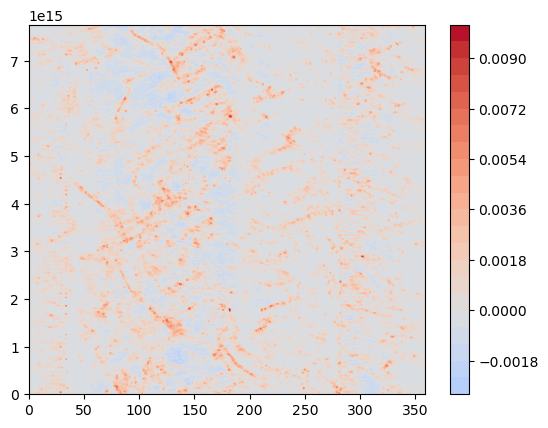

In [19]:
# data = xr.open_dataset("/glade/u/home/sressel/spencer-scratch/graphcast_input_data/202012_202102/era5_data.nc")
plt.contourf(
    data['specific_humidity'].lon,
    data['specific_humidity'].time,
    data['total_precipitation_6hr'].sel(batch=0, lat=slice(-15,15)).mean(dim='lat').stats.standardize(dim='time'),
    levels=21,
    cmap='coolwarm',
    norm=mcolors.CenteredNorm(vcenter=0)
)
plt.colorbar()

In [17]:
data


<xarray.Dataset> Size: 8GB
Dimensions:                       (batch: 1, time: 360, lat: 181, lon: 360,
                                   level: 13)
Coordinates:
  * lat                           (lat) float64 1kB -90.0 -89.0 ... 89.0 90.0
  * lon                           (lon) float64 3kB 0.0 1.0 2.0 ... 358.0 359.0
    datetime                      (batch, time) datetime64[ns] 3kB ...
  * time                          (time) timedelta64[ns] 3kB 0 days 00:00:00 ...
  * level                         (level) int32 52B 50 100 150 ... 850 925 1000
    number                        int64 8B ...
    expver                        (time) <U4 6kB ...
Dimensions without coordinates: batch
Data variables: (12/14)
    10m_u_component_of_wind       (batch, time, lat, lon) float32 94MB ...
    10m_v_component_of_wind       (batch, time, lat, lon) float32 94MB ...
    2m_temperature                (batch, time, lat, lon) float32 94MB ...
    geopotential                  (batch, time, level, lat, lon) float32 1GB ...
    geopotential_at_surface       (lat, lon) float32 261kB ...
    land_sea_mask                 (lat, lon) float32 261kB ...
    ...                            ...
    temperature                   (batch, time, level, lat, lon) float32 1GB ...
    toa_incident_solar_radiation  (batch, time, lat, lon) float32 94MB ...
    total_precipitation_6hr       (batch, time, lat, lon) float32 94MB ...
    u_component_of_wind           (batch, time, level, lat, lon) float32 1GB ...
    v_component_of_wind           (batch, time, level, lat, lon) float32 1GB ...
    vertical_velocity             (batch, time, level, lat, lon) float32 1GB ...
Attributes:
    regrid_method:  bilinear

In [47]:
# input_duration = np.load("/glade/u/home/sressel/thesis-work/python/graphcast/gc-initial-condition-optimization/params/params_GraphCast_small.npz")['task_config:input_duration']
input_duration = '12h'
# Slice out targets:
targets = new_gc_data.sel({"time": target_lead_times})

input_duration = pd.Timedelta(input_duration)
# Both endpoints are inclusive with label-based slicing, so we offset by a
# small epsilon to make one of the endpoints non-inclusive:
zero = pd.Timedelta(0)
epsilon = pd.Timedelta(1, "ns")
inputs = new_gc_data.sel({"time": slice(-input_duration + epsilon, zero)})

In [107]:
_SEC_PER_HOUR = 3600
_HOUR_PER_DAY = 24
SEC_PER_DAY = _SEC_PER_HOUR * _HOUR_PER_DAY
_AVG_DAY_PER_YEAR = 365.24219
AVG_SEC_PER_YEAR = SEC_PER_DAY * _AVG_DAY_PER_YEAR

DAY_PROGRESS = "day_progress"
YEAR_PROGRESS = "year_progress"
_DERIVED_VARS = {
    DAY_PROGRESS,
    f"{DAY_PROGRESS}_sin",
    f"{DAY_PROGRESS}_cos",
    YEAR_PROGRESS,
    f"{YEAR_PROGRESS}_sin",
    f"{YEAR_PROGRESS}_cos",
}
TISR = "toa_incident_solar_radiation"
def extract_inputs_targets_forcings(
    dataset: xr.Dataset,
    *,
    input_variables: Tuple[str, ...],
    target_variables: Tuple[str, ...],
    forcing_variables: Tuple[str, ...],
    pressure_levels: Tuple[int, ...],
    input_duration: TimedeltaLike,
    target_lead_times: TargetLeadTimes,
    ) -> Tuple[xr.Dataset, xr.Dataset, xr.Dataset]:
  """Extracts inputs, targets and forcings according to requirements."""
  dataset = dataset.sel(level=list(pressure_levels))

  # "Forcings" include derived variables that do not exist in the original ERA5
  # or HRES datasets, as well as other variables (e.g. tisr) that need to be
  # computed manually for the target lead times. Compute the requested ones.
  if set(forcing_variables) & _DERIVED_VARS:
    add_derived_vars(dataset)
  if set(forcing_variables) & {TISR}:
    add_tisr_var(dataset)

  # `datetime` is needed by add_derived_vars but breaks autoregressive rollouts.
  dataset = dataset.drop_vars("datetime")

  inputs, targets = extract_input_target_times(
      dataset,
      input_duration=input_duration,
      target_lead_times=target_lead_times)

  if set(forcing_variables) & set(target_variables):
    raise ValueError(
        f"Forcing variables {forcing_variables} should not "
        f"overlap with target variables {target_variables}."
    )

  inputs = inputs[list(input_variables)]
  # The forcing uses the same time coordinates as the target.
  forcings = targets[list(forcing_variables)]
  targets = targets[list(target_variables)]

  return inputs, targets, forcings

In [92]:
from xarray import load_dataset as xld
from numpy import datetime64
dataset_file_path = "/glade/u/home/sressel/thesis-work/python/graphcast/gc-initial-condition-optimization/data/era5_sample.nc"

init_date = '2022-01-01T06:00:00.000000000'
init_str = init_date[:13]  # Extract the first 13 characters (YYYY-MM-DDTHH)
init_date = datetime64(init_date)
name_path = dataset_file_path.split('/')[-1][5:15]
inter = xld(dataset_file_path).compute()

def drop_time_dim_if_present(ds, var_name):
    if 'time' in ds[var_name].dims:
        return ds[var_name].isel(time=0, drop=True)
    return ds[var_name]

inter = inter.assign(
    geopotential_at_surface=drop_time_dim_if_present(inter, 'geopotential_at_surface'),
    land_sea_mask=drop_time_dim_if_present(inter, 'land_sea_mask')
)
for j,i in enumerate(inter.datetime.values[0]):
    if i==init_date:
        start_index=j-1
        break

example_batch = inter.isel(time=slice(start_index,None))

In [98]:
from logging import info
date_train=str(example_batch.datetime.values[0][1])[:13]
info(date_train)
num_time_steps = len(example_batch.time)
new_time = np.arange(0, num_time_steps * 6 * 3600 * 10**9, 6 * 3600 * 10**9, dtype='timedelta64[ns]')
new_time

2026-05-20 13:58:15,281 [INFO] 2022-01-01T06


array([              0,  21600000000000,  43200000000000,  64800000000000,
        86400000000000, 108000000000000, 129600000000000, 151200000000000,
       172800000000000, 194400000000000, 216000000000000, 237600000000000,
       259200000000000, 280800000000000], dtype='timedelta64[ns]')

In [113]:
inter.swap_dims({'time':'datetime'}).sel(datetime=slice(np.datetime64(init_date)-np.timedelta64(6, "h"),None))

ValueError: replacement dimension 'datetime' is not a 1D variable along the old dimension 'time'

# Analyze optimized data

In [2]:
# data_directory = "/glade/u/home/sressel/spencer-scratch/graphcast_input_data/202012_202102"
# files_list = glob.glob(f"{data_directory}/*.nc")
# for file in files_list:
#     data_name = file.split("/")[-1].split("202012_202102_")[-1]
#     print(data_name)
#     os.system(f"mv {file} {data_name}")

In [3]:
import xarray as xr

input_data = xr.open_dataset("/glade/u/home/sressel/spencer-scratch/graphcast_input_data/202012_202102/era5_data.nc")

In [22]:
optimized_data_array = xr.zeros_like(input_data.isel(time=0, drop=True))
optimized_data = np.load("/glade/u/home/sressel/spencer-scratch/graphcast_output/perfect_model_params/2009-12-26T00/2009-12-26T00_96_40.npz")

In [23]:
# Assign variables with inferred dims
for key in [
    '10m_u_component_of_wind',
    '10m_v_component_of_wind',
    '2m_temperature',
    # 'day_progress_cos',
    # 'day_progress_sin',
    'geopotential',
    'geopotential_at_surface',
    'land_sea_mask',
    'mean_sea_level_pressure',
    'specific_humidity',
    'temperature',
    'toa_incident_solar_radiation',
    'total_precipitation_6hr',
    'u_component_of_wind',
    'v_component_of_wind',
    'vertical_velocity'
]:

    arr = optimized_data[key]

    if arr.ndim == 2:
        optimized_data_array[key] = (("lat", "lon"), arr)

    elif arr.ndim == 3:
        optimized_data_array[key] = (("time", "lat", "lon"), arr)

    elif arr.ndim == 4:
        optimized_data_array[key] = (("batch", "time", "lat", "lon"), arr)

    elif arr.ndim == 5:
        optimized_data_array[key] = (("batch", "time", "level", "lat", "lon"), arr)

    else:
        raise ValueError(f"Don't know how to assign dims for {key} with shape {arr.shape}")

In [9]:
def datetime_to_ns(initial_time, final_time):
    return (final_time.astype("timedelta64[ns]") - initial_time.astype("timedelta64[ns]")).astype("timedelta64[ns]")

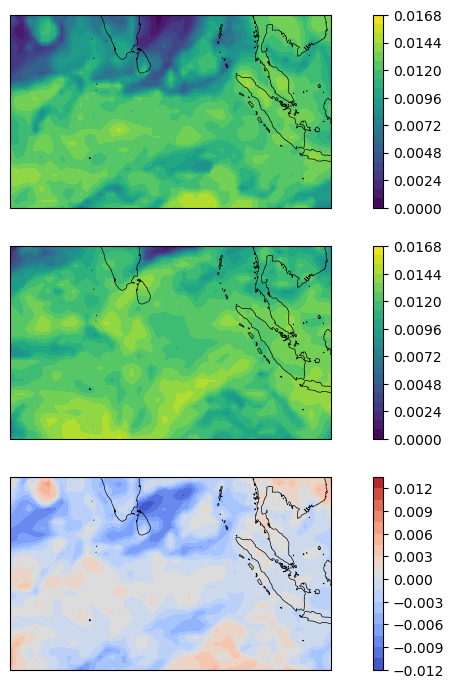

In [24]:
start_date = '2009-12-01T00:00:00.000000000'
end_date = '2010-01-31T00:00:00.000000000'

optimized_day = datetime_to_ns(
    np.datetime64(start_date), np.datetime64('2009-12-26T00:00:00.000000000')
)
level_to_plot = 850
variable_to_plot = 'specific_humidity'

# [fig, ax] = plt.subplots(3, 1, figsize=(12,16))

fig, ax = plt.subplots(nrows=3,ncols=1,
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        figsize=(11,8.5))

i  =0
c_opt = ax[0].contourf(
    optimized_data_array[variable_to_plot].lon,
    optimized_data_array[variable_to_plot].lat,
    optimized_data_array[variable_to_plot].sel(level=level_to_plot).isel(batch=0, time=i),
    levels = 21
)
fig.colorbar(c_opt, ax=ax[0])
ax[0].add_feature(cartopy.feature.COASTLINE, linewidth=0.5)

c_init = ax[1].contourf(
    input_data.lon,
    input_data.lat,
    input_data[variable_to_plot].sel(time=optimized_day, level=level_to_plot).isel(batch=0),
    levels = c_opt.levels
)
fig.colorbar(c_init, ax=ax[1])
ax[1].add_feature(cartopy.feature.COASTLINE, linewidth=0.5)

c_diff = ax[2].contourf(
    input_data.lon,
    input_data.lat,
    (optimized_data_array[variable_to_plot].sel(level=level_to_plot).isel(time=i, batch=0) - input_data[variable_to_plot].sel(time=optimized_day, level=level_to_plot).isel(batch=0)),
    # levels = np.linspace(-0.01, 0.01, 21),
    levels=21,
    cmap = 'coolwarm'
)
fig.colorbar(c_diff, ax=ax[2])
ax[2].add_feature(cartopy.feature.COASTLINE, linewidth=0.5)

# for axis in ax:
#     rect = patches.Rectangle(
#         (70, -10),        # lower-left corner
#         30, 20,   # rectangle size
#         linewidth=1.5,
#         edgecolor='red',
#         facecolor='none',   # or a color like 'lightgray'
#         alpha=0.5
#     )

#     axis.add_patch(rect)

for axis in ax:
    axis.set_xlim(60, 110)
    axis.set_ylim(-15, 15)

plt.show()

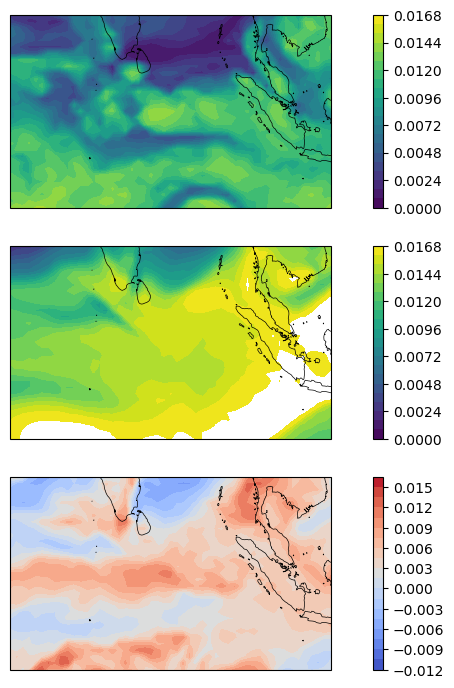

In [6]:
# pred_data = xr.open_zarr("/glade/u/home/sressel/spencer-scratch/graphcast_output/perfect_model_forecasts/2009-12-26T00/2009-12-26T00_40.zarr")
pred_data = xr.open_zarr("/glade/u/home/sressel/spencer-scratch/graphcast_output/perfect_model_forecasts/2021-01-01T00/2021-01-01T00_200.zarr")

start_date = '2020-01-01T00:00:00.000000000'
# end_date = '2021-11-12T00:00:00.000000000'

# optimized_day = datetime_to_ns(
#     np.datetime64(start_date), np.datetime64('2009-12-26T00:00:00.000000000')
# )
level_to_plot = 850
variable_to_plot = 'specific_humidity'

# [fig, ax] = plt.subplots(3, 1, figsize=(12,16))

fig, ax = plt.subplots(nrows=3,ncols=1,
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        figsize=(11,8.5))

i=-1
c_input = ax[0].contourf(
    input_data[variable_to_plot].lon,
    input_data[variable_to_plot].lat,
    input_data[variable_to_plot].sel(level=level_to_plot).isel(batch=0, time=i),
    levels = 21
)
fig.colorbar(c_input, ax=ax[0])
ax[0].add_feature(cfeature.COASTLINE, linewidth=0.5)

c_pred = ax[1].contourf(
    pred_data.lon,
    pred_data.lat,
    pred_data[variable_to_plot].sel(level=level_to_plot).isel(batch=0, time=i),
    levels = c_input.levels
)
fig.colorbar(c_pred, ax=ax[1])
ax[1].add_feature(cfeature.COASTLINE, linewidth=0.5)

c_diff = ax[2].contourf(
    input_data.lon,
    input_data.lat,
    (pred_data[variable_to_plot] - input_data[variable_to_plot]).sel(level=level_to_plot).isel(batch=0, time=i),
    # levels = np.linspace(-0.01, 0.01, 21),
    levels=21,
    cmap = 'coolwarm'
)
fig.colorbar(c_diff, ax=ax[2])
ax[2].add_feature(cfeature.COASTLINE, linewidth=0.5)

for axis in ax:
    axis.set_xlim(60, 110)
    axis.set_ylim(-15, 15)

# for axis in ax:
#     rect = patches.Rectangle(
#         (70, -10),        # lower-left corner
#         30, 20,   # rectangle size
#         linewidth=1.5,
#         edgecolor='red',
#         facecolor='none',   # or a color like 'lightgray'
#         alpha=0.5
#     )

#     axis.add_patch(rect)
plt.show()

In [11]:
predicted_precipitation = pred_data['total_precipitation_6hr'].load().isel(batch=0)

In [12]:
predicted_precipitation

<xarray.DataArray 'total_precipitation_6hr' (time: 200, lat: 181, lon: 360)> Size: 104MB
array([[[ 3.87428299e-05,  3.75828640e-05,  3.96708019e-05, ...,
          3.66548920e-05,  3.87428299e-05,  3.41029699e-05],
        [ 2.52872360e-05,  2.43592640e-05,  2.34312920e-05, ...,
          2.09953650e-05,  2.23873230e-05,  2.45912561e-05],
        [ 3.42189651e-06,  3.65388951e-06,  5.04584750e-06, ...,
         -6.43780550e-06,  1.10196663e-06,  6.37980690e-07],
        ...,
        [ 5.79587708e-04,  5.64394519e-04,  5.35758561e-04, ...,
          6.42437546e-04,  6.28042500e-04,  6.04291912e-04],
        [ 4.25569306e-04,  4.14910493e-04,  4.10747452e-04, ...,
          4.20955126e-04,  4.38612304e-04,  4.20027180e-04],
        [ 2.35176238e-04,  2.33320286e-04,  2.31464335e-04, ...,
          2.33320286e-04,  2.27752462e-04,  2.31464335e-04]],

       [[ 3.04490804e-05,  2.97531005e-05,  3.20730323e-05, ...,
          3.13770506e-05,  3.18410384e-05,  2.60412125e-05],
        [ 3.71188798e-06,  4.40786789e-06,  4.17587398e-06, ...,
          1.50795495e-06,  5.79982952e-07,  2.55192208e-06],
        [-5.79982498e-06, -1.14256545e-05, -1.30496046e-05, ...,
         -1.75154710e-05, -1.83854427e-05, -1.60655127e-05],
...
        [ 2.42379509e-04,  2.51373422e-04,  2.43035116e-04, ...,
          2.35807398e-04,  2.35038300e-04,  2.44642171e-04],
        [ 2.78945285e-04,  2.72812991e-04,  2.71432160e-04, ...,
          2.68297357e-04,  2.70237098e-04,  2.73577112e-04],
        [ 1.27236912e-04,  1.24281767e-04,  1.20974859e-04, ...,
          1.16036688e-04,  1.19409924e-04,  1.15699848e-04]],

       [[ 8.70526274e-05,  8.84425608e-05,  7.77085734e-05, ...,
          8.85016852e-05,  9.09403025e-05,  8.74015459e-05],
        [-3.77810968e-04, -3.98684148e-04, -4.42182762e-04, ...,
          1.03408223e-04, -8.64237591e-05, -2.81180925e-04],
        [ 1.15586103e-04,  1.19528944e-04,  1.14308095e-04, ...,
          1.23701961e-04,  1.18426149e-04,  1.34259186e-04],
        ...,
        [ 2.44525436e-04,  2.44703609e-04,  2.42743306e-04, ...,
          2.40273264e-04,  2.37416229e-04,  2.44004186e-04],
        [ 2.45770294e-04,  2.30822261e-04,  2.36401218e-04, ...,
          2.38834240e-04,  2.37526081e-04,  2.39938134e-04],
        [ 5.25351716e-05,  5.60758272e-05,  5.60168264e-05, ...,
          4.45828482e-05,  4.84200718e-05,  4.98138397e-05]]])
Coordinates:
    expver   (time) <U4 3kB '0001' '0001' '0001' '0001' ... '0001' '0001' '0001'
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
    number   int64 8B 0
  * time     (time) timedelta64[ns] 2kB 0 days 06:00:00 ... 50 days 00:00:00

# Analyze predicted data

In [203]:
era5_data = xr.load_dataset("/glade/u/home/sressel/spencer-scratch/graphcast_input_data/199208_199211/era5_data.nc").load()
era5_data = convert_ns_to_datetime(era5_data, '1992-08-01').swap_dims({'time':'datetime'})
pred_data = xr.open_zarr("/glade/u/home/sressel/spencer-scratch/graphcast_output/perfect_model_forecasts/1992-08-11T00/1992-08-11T00_120.zarr").load()
# pred_data = xr.open_zarr("/glade/u/home/sressel/spencer-scratch/graphcast_output/perfect_model_forecasts/1992-08-14T00/1992-08-14T00_364.zarr")
pred_data = convert_ns_to_datetime(pred_data, "1992-08-10T18").swap_dims({'time':'datetime'})

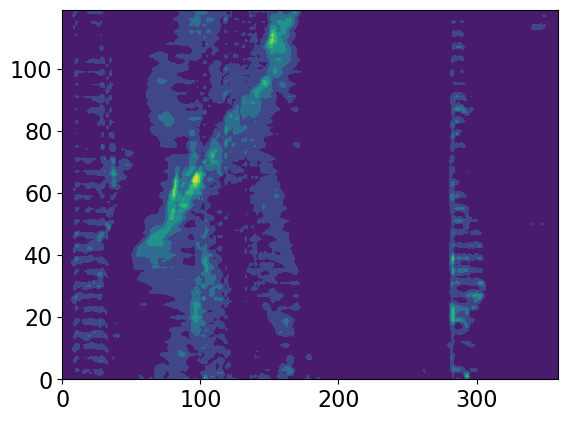

In [165]:
plt.contourf(pred_data['total_precipitation_6hr'].isel(batch=0).sel(lat=slice(-5,5)).mean(dim='lat'))

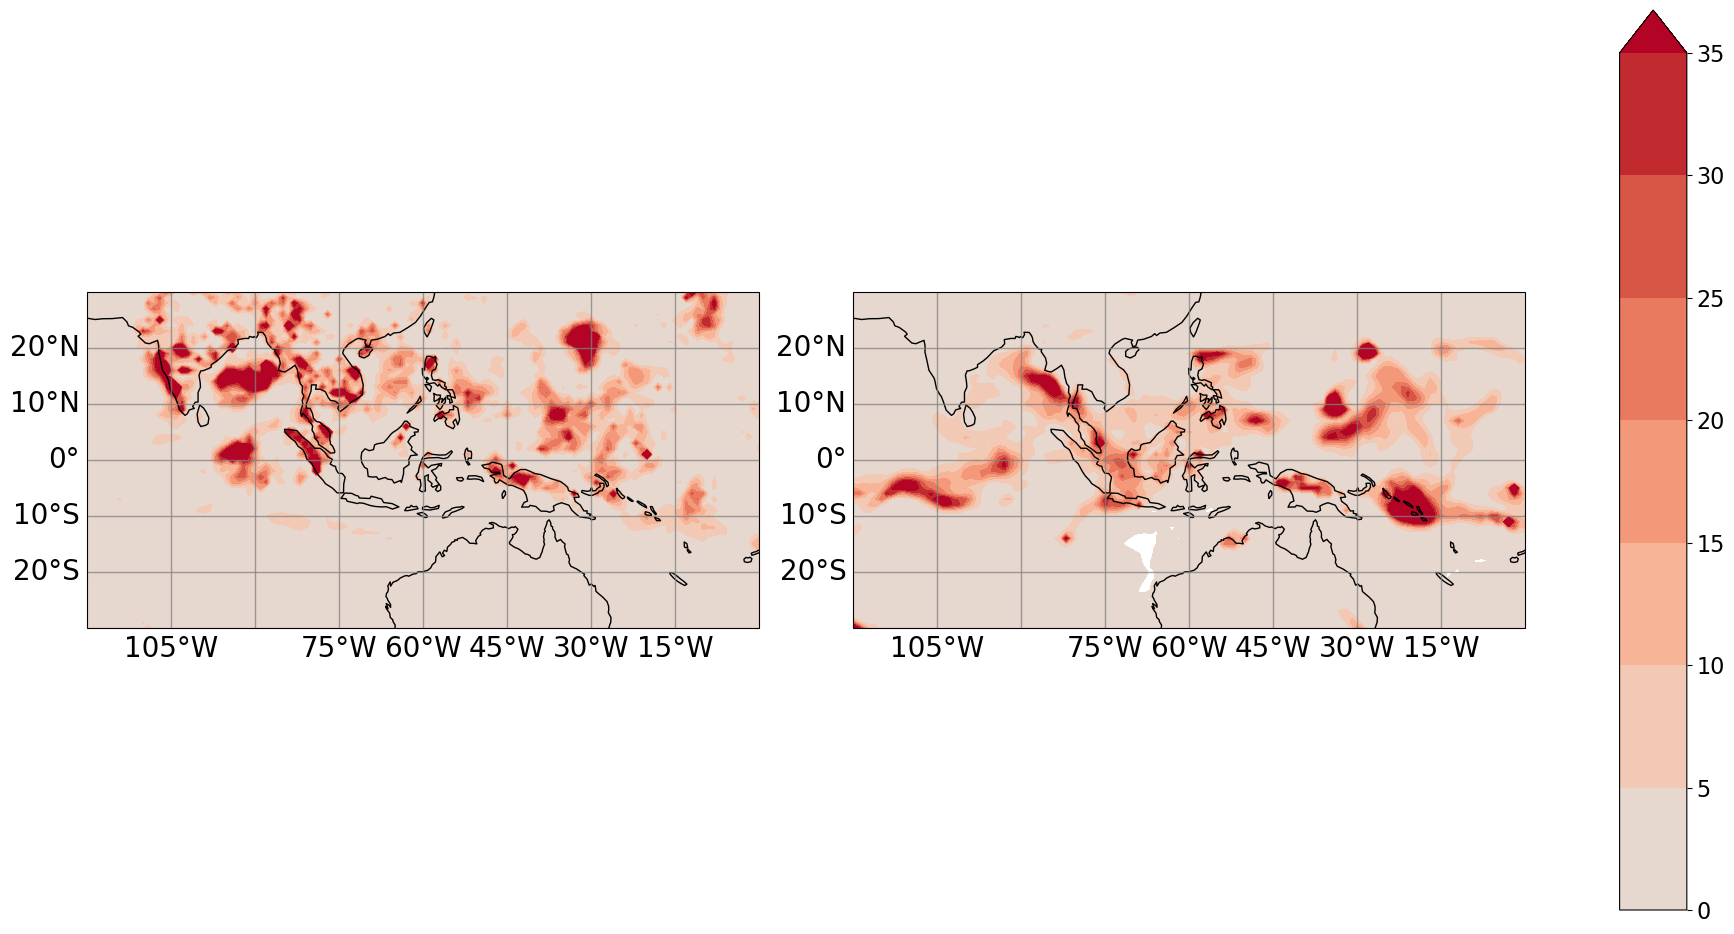

In [204]:
variable_to_plot = 'total_precipitation_6hr'
time_to_plot = "1992-08-11T06"

plt.rcParams.update({'font.size':16})
fig = plt.figure(figsize=(16,9))
gs = GridSpec(1, 3, figure=fig, width_ratios=[100, 100, 10])
gs.update(top=1, bottom=0, left=0, right=1, wspace=0.2)

central_longitude = -180
proj = ccrs.PlateCarree(central_longitude=central_longitude)
data_crs = ccrs.PlateCarree()
coastline_width = 1


ax = [
    fig.add_subplot(gs[0], projection=proj),
    fig.add_subplot(gs[1], projection=proj),
]
cbar_ax = fig.add_subplot(gs[2])

# cdata_era5 = xarray_utils.add_cyclic_point(
#     4000*era5_data['total_precipitation_6hr'],
#     dim='lon'
# ).isel(batch=0).sel(lat=slice(-30, 30), lon=slice(60, 180), datetime="1992-08-14T06"),

# cdata_pred = xarray_utils.add_cyclic_point(
#     4000*pred_data['total_precipitation_6hr'],
#     dim='lon'
# ).isel(batch=0).sel(lat=slice(-30, 30), lon=slice(60, 180), datetime="1992-08-14T06"),

im = ax[0].contourf(
    era5_data.lon,
    era5_data.lat,
    (4000*era5_data[variable_to_plot]).isel(batch=0).sel(datetime=time_to_plot),
    levels=np.arange(0, 40, 5), 
    # levels=np.linspace(-21, 21, 21),
    transform=data_crs,
    cmap='coolwarm', 
    norm=mcolors.CenteredNorm(vcenter=0),
    extend='max'
)

ax[1].contourf(
    pred_data.lon,
    pred_data.lat,
    (4000*pred_data[variable_to_plot]).isel(batch=0).sel(datetime=time_to_plot),
    # levels=np.arange(0, 27.5, 2.5), 
    levels=im.levels, 
    transform=data_crs,
    cmap='coolwarm', 
    norm=mcolors.CenteredNorm(vcenter=0),
    extend='max'
)

# Add colorbar
cbar = fig.colorbar(im, cax=cbar_ax)

for axis in ax:
    axis.add_feature(cfeature.COASTLINE, lw=coastline_width)
    axis.set_xlim(central_longitude+60, central_longitude+180)
    axis.set_ylim(-30, 30)
    gl = axis.gridlines(
        crs=proj,
        draw_labels=True,
        linewidth=1,
        color="gray",
        alpha=0.75,
        linestyle="-",
        zorder=15
    )
    gl.right_labels = False
    gl.top_labels = False
    gl.xlocator = mticker.FixedLocator(central_longitude+np.arange(60,210,15))
    # gl.xlocator = LongitudeLocator(30)
    gl.xformatter = LongitudeFormatter()
    gl.xlabel_style = {'fontsize':20}
    gl.ylocator = mticker.FixedLocator(np.arange(-40,40,10))
    gl.yformatter = LatitudeFormatter()
    gl.ylabel_style = {'fontsize':20}

plt.show()

In [100]:
meridional_mean_graphcast_precip = pred_data['total_precipitation_6hr'].sel(lat=slice(-15,15)).mean(dim='lat')
meridional_mean_era5_precip = era5_data['total_precipitation_6hr'].sel(lat=slice(-15,15)).mean(dim='lat')

In [46]:
print(4000*meridional_mean_graphcast_precip.isel(batch=0).min().values, 4000*meridional_mean_graphcast_precip.isel(batch=0).max().values)

0.08542740529678254 55.12412197210572


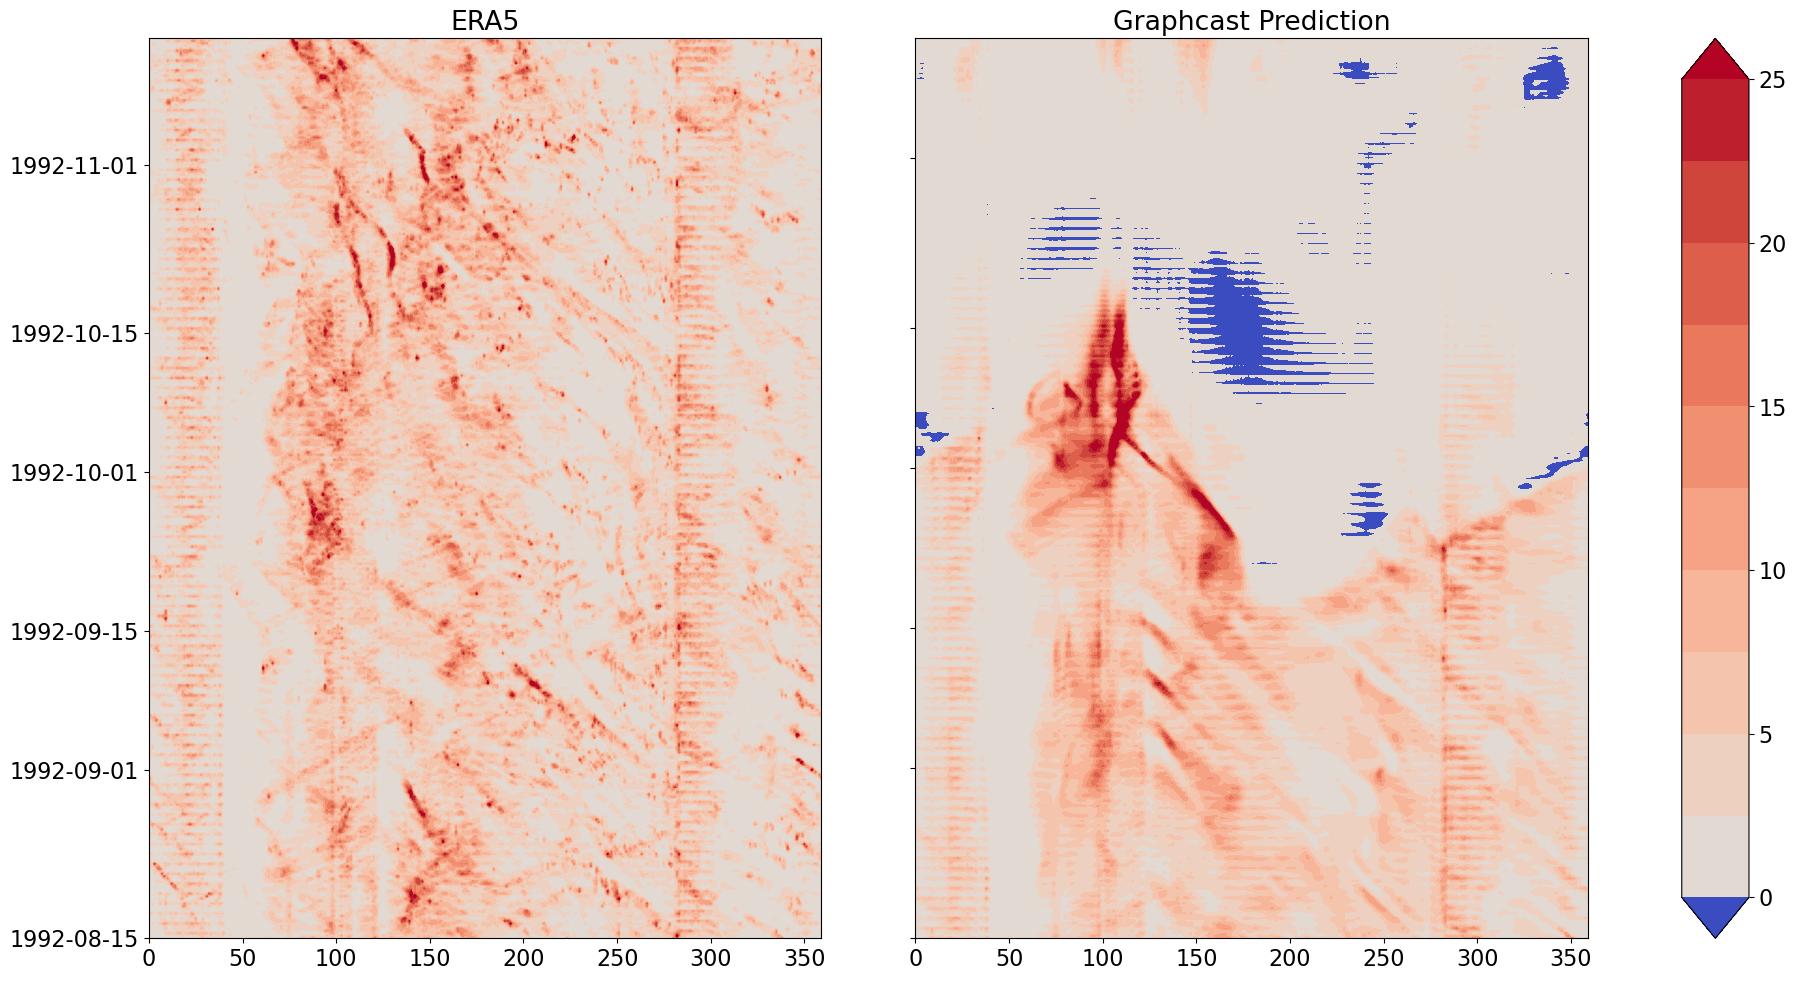

In [118]:
plt.rcParams.update({'font.size':16})
fig = plt.figure(figsize=(16,9))
gs = GridSpec(1, 3, figure=fig, width_ratios=[100, 100, 10])
gs.update(top=1, bottom=0, left=0, right=1, wspace=0.2)

ax = [
    fig.add_subplot(gs[0]),
    fig.add_subplot(gs[1]),
    fig.add_subplot(gs[2]),
]

plotting_dates = slice(
    "1992-08-15",
    "1992-11-13"
)

ax[0].set_title('ERA5')
ax[0].contourf(
    meridional_mean_era5_precip.lon,
    meridional_mean_era5_precip.datetime.sel(datetime=plotting_dates),
    4000*meridional_mean_era5_precip.isel(batch=0).sel(datetime=plotting_dates),
    levels=np.arange(0, 27.5, 2.5),
    extend='both',
    cmap='coolwarm',
    norm=mcolors.CenteredNorm(vcenter=0)
)

ax[1].set_title('Graphcast Prediction')
im = ax[1].contourf(
    meridional_mean_graphcast_precip.lon,
    meridional_mean_graphcast_precip.datetime.sel(datetime=plotting_dates),
    4000*meridional_mean_graphcast_precip.isel(batch=0).sel(datetime=plotting_dates),
    levels=np.arange(0, 27.5, 2.5),
    extend='both',
    cmap='coolwarm',
    norm=mcolors.CenteredNorm(vcenter=0)
)

ax[1].set_yticklabels('')

fig.colorbar(im, cax=ax[-1])

plt.show()

<xarray.DataArray 'total_precipitation_6hr' (batch: 1, datetime: 488, lat: 181,
                                             lon: 360)> Size: 127MB
array([[[[4.76837158e-06, 4.76837158e-06, 4.76837158e-06, ...,
          4.76837158e-06, 4.76837158e-06, 4.76837158e-06],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         ...,
         [1.42574310e-04, 1.39713287e-04, 1.36852264e-04, ...,
          1.55448914e-04, 1.52111053e-04, 1.46865845e-04],
         [2.07424164e-04, 2.04086304e-04, 2.01702118e-04, ...,
          1.97887421e-04, 2.01225281e-04, 2.04086304e-04],
         [2.61783600e-04, 2.61783600e-04, 2.61783600e-04, ...,
          2.61783600e-04, 2.61783600e-04, 2.61783600e-04]],

        [[1.43051147e-06, 1.43051147e-06, 1.43051147e-06, ...,
          1.43051147e-06, 1.43051147e-06, 1.43051147e-06],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
...
          6.43730164e-05, 7.15255737e-05, 7.86781311e-05],
         [5.72204590e-05, 6.00814819e-05, 6.29425049e-05, ...,
          4.57763672e-05, 4.91142273e-05, 5.24520874e-05],
         [2.71797180e-05, 2.71797180e-05, 2.71797180e-05, ...,
          2.71797180e-05, 2.71797180e-05, 2.71797180e-05]],

        [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         ...,
         [1.29699707e-04, 1.35898590e-04, 1.43051147e-04, ...,
          1.17301941e-04, 1.21593475e-04, 1.25885010e-04],
         [1.83582306e-04, 1.90258026e-04, 1.97410583e-04, ...,
          1.69277191e-04, 1.73568726e-04, 1.79290771e-04],
         [1.80244446e-04, 1.80244446e-04, 1.80244446e-04, ...,
          1.80244446e-04, 1.80244446e-04, 1.80244446e-04]]]],
      dtype=float32)
Coordinates:
  * lat       (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon       (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * datetime  (datetime) datetime64[ns] 4kB 1992-08-01 ... 1992-11-30T18:00:00
    time      (datetime) timedelta64[ns] 4kB 0 days 00:00:00 ... 121 days 18:...
    number    int64 8B 0
    expver    (datetime) <U4 8kB '0001' '0001' '0001' ... '0001' '0001' '0001'
Dimensions without coordinates: batch
Attributes:
    regrid_method:  bilinear

In [19]:
meridional_mean_era5_precip.isel(batch=0)

<xarray.DataArray 'total_precipitation_6hr' (time: 488, lon: 360)> Size: 703kB
array([[1.01002777e-04, 1.43181198e-04, 1.56836075e-04, ...,
        1.96630310e-04, 1.27315521e-04, 9.95289229e-05],
       [7.94150619e-05, 1.15871429e-04, 1.10842964e-04, ...,
        1.92858963e-04, 1.25018036e-04, 8.19726411e-05],
       [2.52290210e-05, 3.24249268e-05, 4.34355316e-05, ...,
        7.16122740e-05, 1.18212265e-04, 2.82200908e-05],
       ...,
       [1.90084626e-04, 1.83972443e-04, 1.57009476e-04, ...,
        2.77475890e-04, 2.25153839e-04, 1.32604080e-04],
       [7.45599900e-05, 8.26662217e-05, 1.19859520e-04, ...,
        7.26959915e-05, 6.48065034e-05, 5.43594360e-05],
       [3.64000152e-04, 2.51379883e-04, 1.28052445e-04, ...,
        2.18261368e-04, 2.97416351e-04, 3.23772430e-04]], dtype=float32)
Coordinates:
  * lon       (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
    datetime  (time) datetime64[ns] 4kB 1992-08-01 ... 1992-11-30T18:00:00
  * time      (time) timedelta64[ns] 4kB 0 days 00:00:00 ... 121 days 18:00:00
    number    int64 8B 0
    expver    (time) <U4 8kB '0001' '0001' '0001' ... '0001' '0001' '0001'

In [38]:
optimized_data.files

['10m_u_component_of_wind',
 '10m_v_component_of_wind',
 '2m_temperature',
 'day_progress_cos',
 'day_progress_sin',
 'geopotential',
 'geopotential_at_surface',
 'land_sea_mask',
 'mean_sea_level_pressure',
 'specific_humidity',
 'temperature',
 'toa_incident_solar_radiation',
 'total_precipitation_6hr',
 'u_component_of_wind',
 'v_component_of_wind',
 'vertical_velocity',
 'year_progress_cos',
 'year_progress_sin']